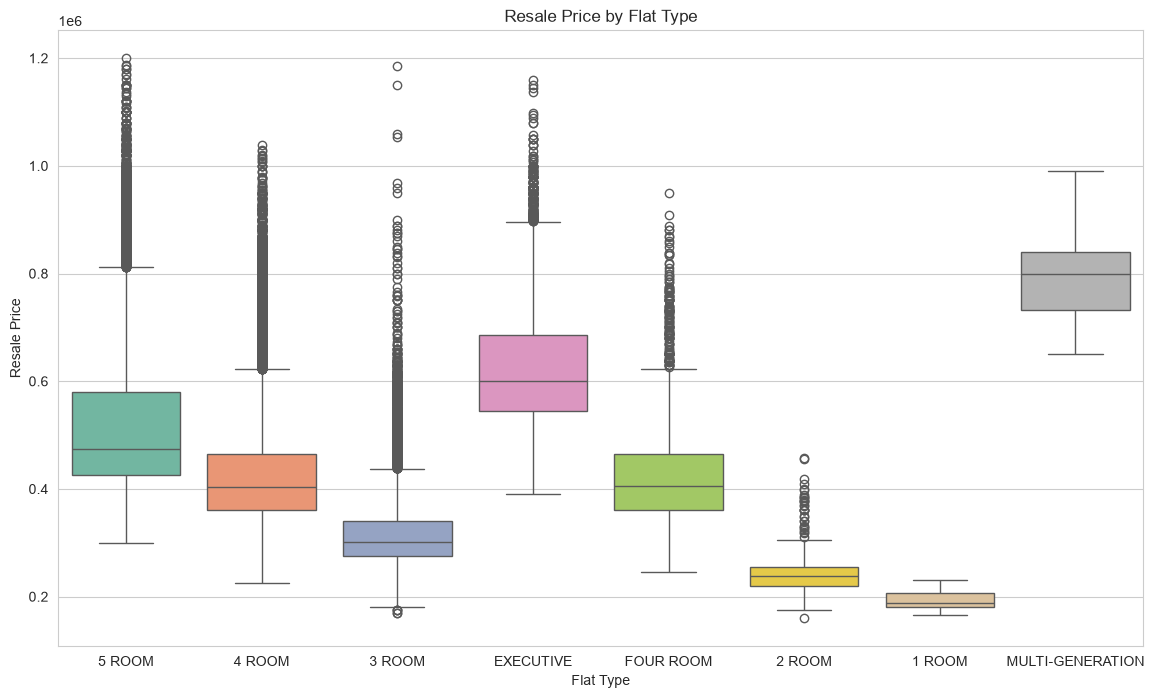

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./regression/data/resale_transactions.csv')

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='flat_type', y='resale_price', data=df, hue='flat_type', palette='Set2')  
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price')
plt.xticks(rotation=0)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["resale_price"])
y = df["resale_price"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import re

# Load data
df = pd.read_csv('./regression/data/resale_transactions.csv')

def extract_lease_info(lease_str: str) -> int:
    """
    Convert lease information from a string format to total months.

    This function takes a string representing the remaining lease period, which
    may include years and months in various formats (e.g., "70 years 3 months",
    "85 years", "67"), and converts it to the total number of months.

    Args:
        lease_str (str): The remaining lease period as a string.

    Returns:
        int: The total number of months, or None if the input is NaN.
    """

    if pd.isna(lease_str):
        return None
    
    # Regular expression to extract years and months
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str)
    number_match = re.match(r'^\d+$', lease_str.strip())
    
    if years_match:
        years = int(years_match.group(1))
    elif number_match:  # If only a number is present, assume it's in years
        years = int(number_match.group(0))
    else:
        years = 0
        
    months = int(months_match.group(1)) if months_match else 0
    
    # Convert the total lease period to months
    total_months = years * 12 + months
    return total_months

# Extract lease information  
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info)

df['year_month'] = pd.to_datetime(df['month'], format='%Y-%m')
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

df = df.drop(columns=['year_month'])

df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')

# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

# Separate predictors and target
X = df.drop(columns=['resale_price'])
y = df['resale_price']

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Define preprocessing
preprocessor = ColumnTransformer(
    n_jobs=-1,
    remainder="drop",
    transformers=[
        (
            "num",
            Pipeline(steps=[
                (
                    'scaler', 
                    StandardScaler()
                )
            ]),
            [
                "floor_area_sqm",
                "remaining_lease_months",
                "lease_commence_date",
                "year"
            ]
        ),
        (
            "nom",
            Pipeline(steps=[('onehot', OneHotEncoder())]
                     ),
            ["month", "town_name", "flatm_name"]
        ),
        (
            "ord",
            Pipeline(steps=[(
                'ordinal',
                OrdinalEncoder(categories=[['1 ROOM', '2 ROOM', 
                '3 ROOM', '4 ROOM', '5 ROOM', 
                'MULTI-GENERATION', 'EXECUTIVE']]
                ))]),
            ["flat_type"]
        ),
        (
            "pass",
            "passthrough",
            ["storey_range"]
        )
    ]
)

Pipeline(steps=[('preprocessor',
    ColumnTransformer(n_jobs=-1, remainder='passthrough',
        transformers=[('num',
            Pipeline(steps=[('scaler', StandardScaler())]),
            ['floor_area_sqm', 'remaining_lease_months',
             'lease_commence_date', 'year']),
        ('nom',
            Pipeline(steps=[('onehot', OneHotEncoder())]),
            ['month', 'town_name', 'flatm_name']),
        ('ord',
            Pipeline(steps=[(
                'ordinal',
                OrdinalEncoder(categories=[['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 
                'MULTI-GENERATION', 'EXECUTIVE'
                ]]
                )
            )]),
            ['flat_type']),
        ('pass', 'passthrough', ['storey_range'])])),
    ('regressor', LinearRegression())])


# Create the pipeline with a linear regression model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

df=df.drop(columns=['remaining_lease'])

# Fit the pipeline to the training data
lr_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = lr_pipeline.predict(X_val)

print("Model trained successfully.")



Model trained successfully.


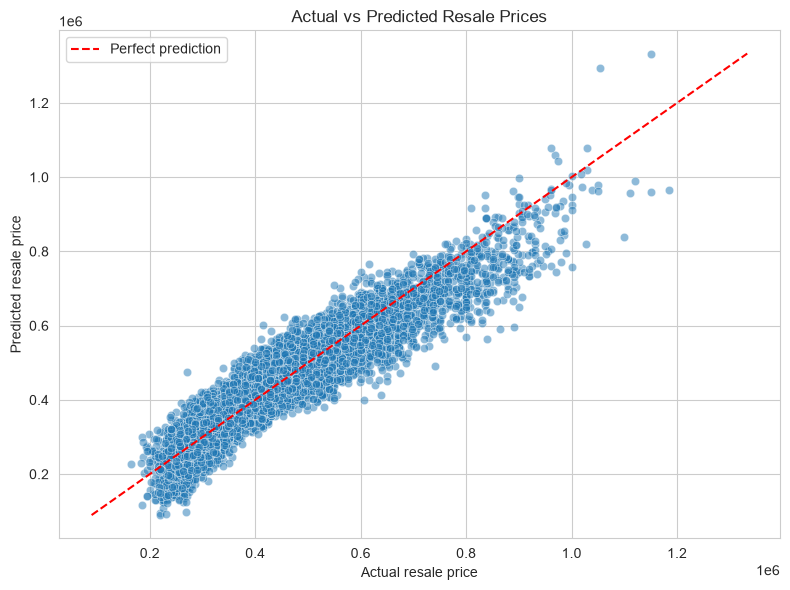

In [7]:
# plot the predictions against the actual values

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_val,
    y=y_val_pred,
    alpha=0.5
)

# Perfect-prediction reference line
minimum = min(y_val.min(), y_val_pred.min())
maximum = max(y_val.max(), y_val_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual resale price")
plt.ylabel("Predicted resale price")
plt.title("Actual vs Predicted Resale Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# performance metrics:

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Calculate regression metrics for validation set
val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)  # RMSE is the square root of MSE
val_r2 = r2_score(y_val, y_val_pred)

# Display the metrics
print(f"Validation MAE: {val_mae}")
print(f"Validation MSE: {val_mse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Validation R2: {val_r2}")

Validation MAE: 41479.151146034725
Validation MSE: 2922151724.891172
Validation RMSE: 54056.93040574143
Validation R2: 0.8654619082607382


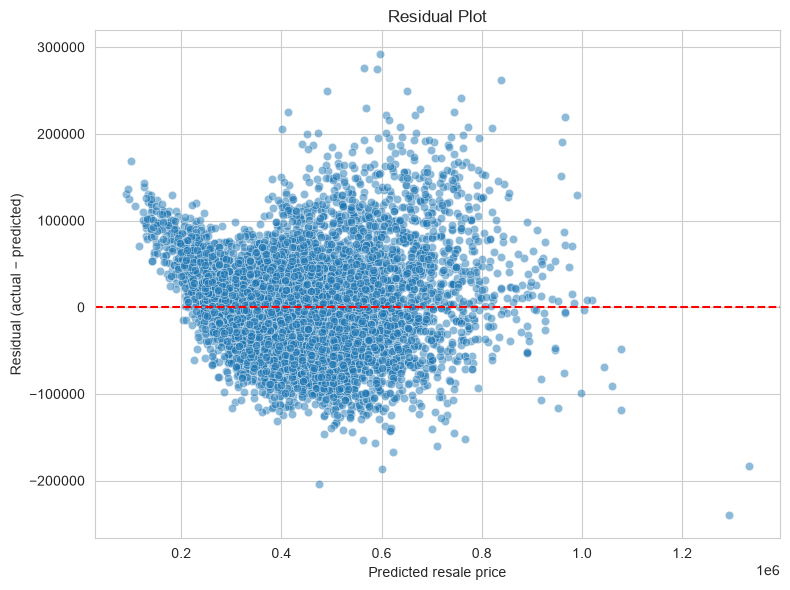

In [9]:
# residual plot

residuals = y_val.to_numpy() - y_val_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_val_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted resale price")
plt.ylabel("Residual (actual − predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

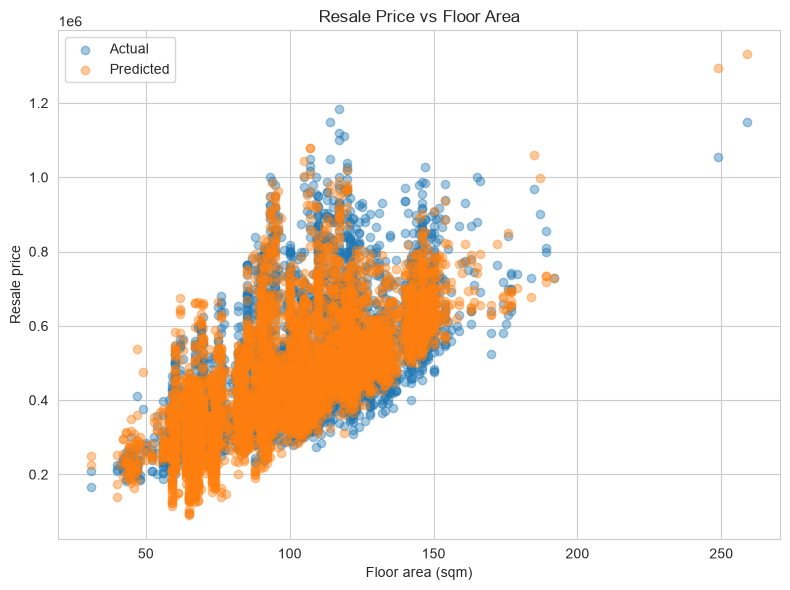

In [10]:
# price against one input feature

plt.figure(figsize=(8, 6))

plt.scatter(
    X_val["floor_area_sqm"],
    y_val,
    alpha=0.4,
    label="Actual"
)

plt.scatter(
    X_val["floor_area_sqm"],
    y_val_pred,
    alpha=0.4,
    label="Predicted"
)

plt.xlabel("Floor area (sqm)")
plt.ylabel("Resale price")
plt.title("Resale Price vs Floor Area")
plt.legend()
plt.tight_layout()
plt.show()

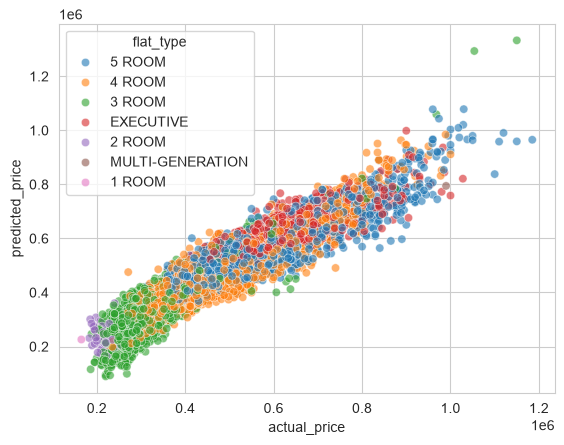

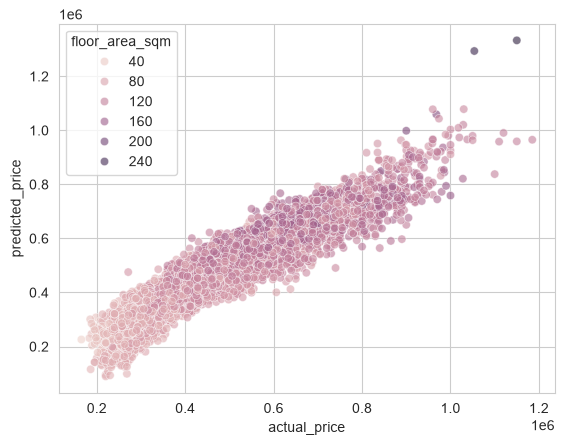

In [11]:
# use Seaborn plot

plot_data = X_val.copy()
plot_data["actual_price"] = y_val
plot_data["predicted_price"] = y_val_pred

sns.scatterplot(
    data=plot_data,
    x="actual_price",
    y="predicted_price",
    hue="flat_type",
    alpha=0.6
)
plt.show()

sns.scatterplot(
    data=plot_data,
    x="actual_price",
    y="predicted_price",
    hue="floor_area_sqm",
    alpha=0.6
)

plt.show()

In [12]:
from sklearn.linear_model import Ridge

# Fit Ridge Regression with lambda (alpha in scikit-learn)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1))
])
ridge_pipeline.fit(X_train, y_train)

# Predict on the validation set with Ridge Regression
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Ridge Regression
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Display the metrics for Ridge Regression
print("Ridge Regression Metrics:")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R²: {val_r2_ridge}")

Ridge Regression Metrics:
Ridge Validation MAE: 41478.51007507436
Ridge Validation MSE: 2922766532.0564013
Ridge Validation RMSE: 54062.61677033772
Ridge Validation R²: 0.8654336020704425


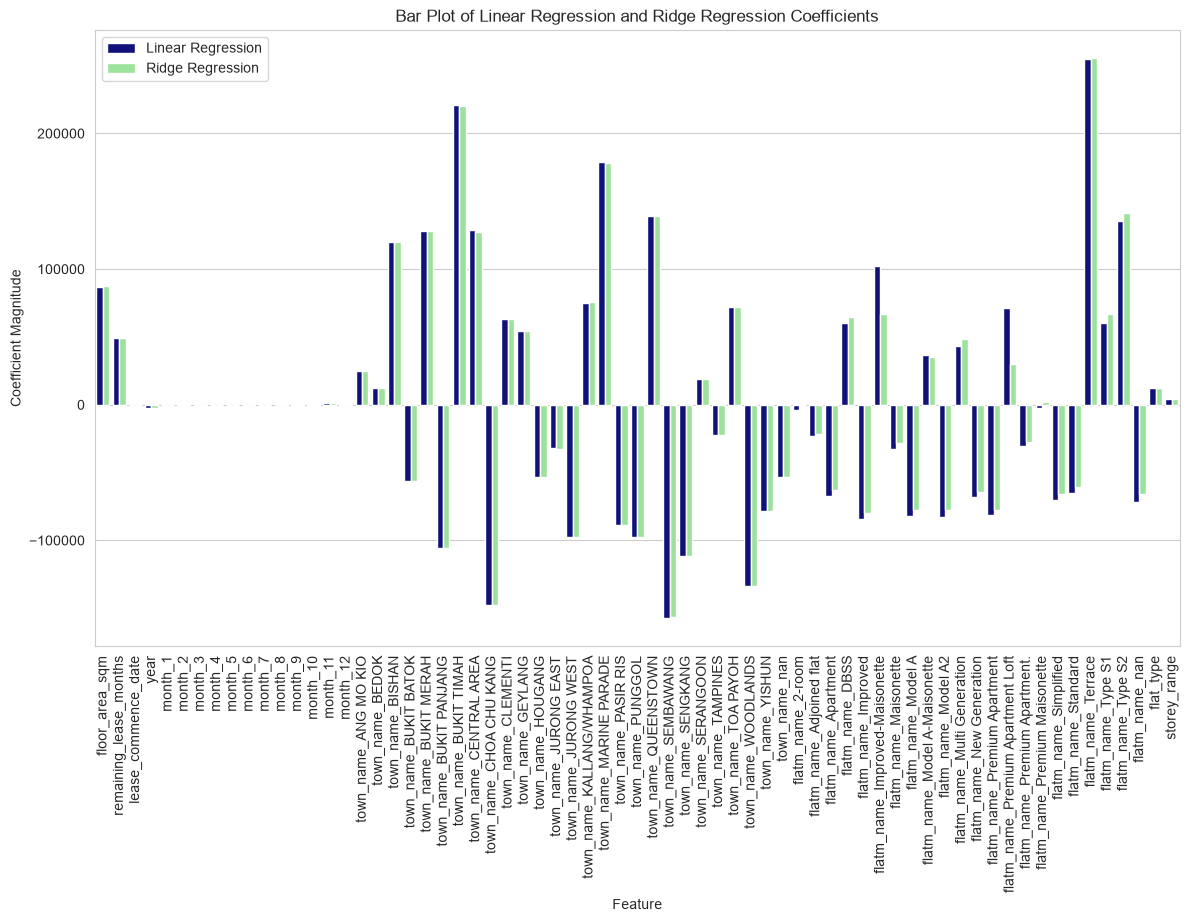

In [13]:
# Extract the coefficients of the linear regression model
lr_coefs = lr_pipeline.named_steps['regressor'].coef_

# Extract the coefficients of the ridge regression model
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_

# Define numerical features to be standardized
numerical_features = ['floor_area_sqm', 'remaining_lease_months', 'lease_commence_date', 'year']

# Define nomial features to be one-hot encoded
nominal_features = ['month', 'town_name', 'flatm_name']

# Define ordinal features to be ordinally encoded
ordinal_features = ['flat_type']

# Define passthrough features that will not be transformed
passthrough_features = ['storey_range']

# Assuming feature_names contains the names of the features after preprocessing
feature_names = (
    numerical_features +
    list(ridge_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Ridge Regression': ridge_coefs
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'lightgreen'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Ridge Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

In [14]:
from sklearn.linear_model import Lasso

# Fit Lasso Regression with default alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1))
])
lasso_pipeline.fit(X_train, y_train)

# Predict on the validation set with Lasso Regression
y_val_pred_lasso = lasso_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Lasso Regression
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

# Display the metrics for Lasso Regression
print("Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")
print(f"Lasso Validation R²: {val_r2_lasso}")

Lasso Regression Metrics:
Lasso Validation MAE: 41479.192812655
Lasso Validation MSE: 2922252911.908255
Lasso Validation RMSE: 54057.86632774415
Lasso Validation R²: 0.8654572495333794


C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.954137e+13, tolerance: 1.527e+11
  model = cd_fast.sparse_enet_coordinate_descent(


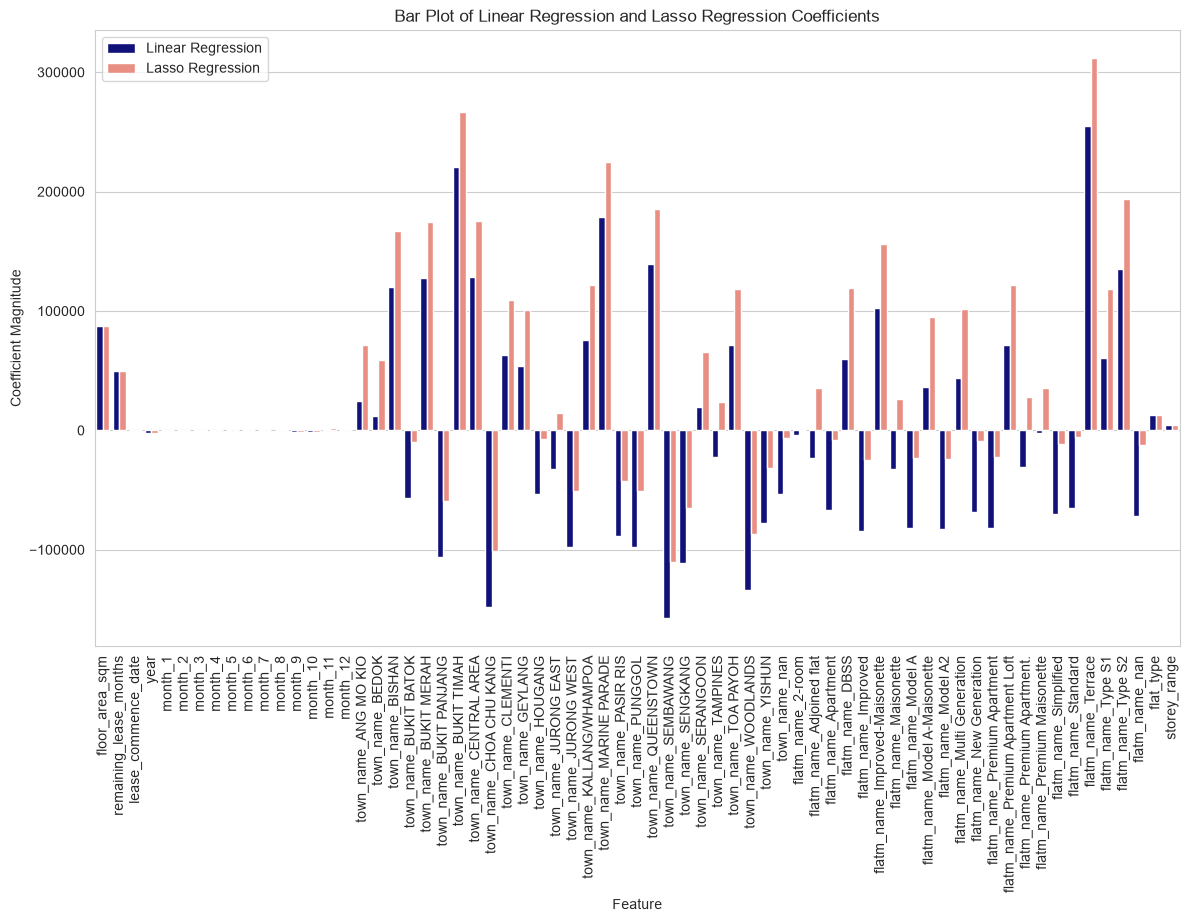

In [15]:
# Extract the coefficients of the linear and lasso regression models
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_

# Extract feature names after preprocessing
feature_names = (
    numerical_features +
    list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Lasso Regression': lasso_coefs
})


# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'salmon'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Lasso Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform grid search with cross-validation for Ridge regression
ridge_grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid_search.fit(X_train, y_train)

# Perform grid search with cross-validation for Lasso regression
lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, y_train)

C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.005976e+13, tolerance: 1.527e+11
  model = cd_fast.sparse_enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.1, 1, ...], 'regressor__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbo

In [17]:
# Print the best parameters found by grid search for Ridge regression
print("Best Ridge parameters:", ridge_grid_search.best_params_)

# Print the best parameters found by grid search for Lasso regression
print("Best Lasso parameters:", lasso_grid_search.best_params_)

Best Ridge parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
Best Lasso parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}


In [18]:
# Evaluate the best Ridge model on the validation set
best_ridge_model = ridge_grid_search.best_estimator_
y_val_pred_ridge = best_ridge_model.predict(X_val)

# Calculate regression metrics for validation set for Ridge
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("Best Ridge Regression Metrics:")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R²: {val_r2_ridge}")

# Evaluate the best Lasso model on the validation set
best_lasso_model = lasso_grid_search.best_estimator_
y_val_pred_lasso = best_lasso_model.predict(X_val)

# Calculate regression metrics for validation set for Lasso
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("Best Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")  
print(f"Lasso Validation R²: {val_r2_lasso}")

Best Ridge Regression Metrics:
Ridge Validation MAE: 41480.35828408724
Ridge Validation MSE: 2923028968.4685817
Ridge Validation RMSE: 54065.043868183275
Ridge Validation R²: 0.865421519298081
Best Lasso Regression Metrics:
Lasso Validation MAE: 41479.0125891522
Lasso Validation MSE: 2922108372.662575
Lasso Validation RMSE: 54056.52941747717
Lasso Validation R²: 0.865463904230372


In [19]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for hyperparameter tuning
param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform randomized search with cross-validation for Ridge regression
ridge_random_search = RandomizedSearchCV(ridge_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
ridge_random_search.fit(X_train, y_train)

# Perform randomized search with cross-validation for Lasso regression
lasso_random_search = RandomizedSearchCV(lasso_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
lasso_random_search.fit(X_train, y_train)

C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\W105417\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.005976e+13, tolerance: 1.527e+11
  model = cd_fast.sparse_enet_coordinate_descent(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__alpha': [0.1, 1, ...], 'regressor__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_inde

In [20]:
# Print the best parameters found by random search for Ridge regression
print("Best Ridge parameters:", ridge_random_search.best_params_)

# Print the best parameters found by random search for Lasso regression
print("Best Lasso parameters:", lasso_random_search.best_params_)

Best Ridge parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}
Best Lasso parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}


In [21]:
# Best model from Ridge regression (Grid Search)
best_ridge_model = ridge_grid_search.best_estimator_

# Predict on the test set with Ridge Regression
y_test_pred_ridge = best_ridge_model.predict(X_test)

# Calculate regression metrics for the test set for Ridge
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_rmse_ridge = root_mean_squared_error(y_test, y_test_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("Best Ridge Regression Model, Final test Metrics:")
print(f"Final Test MAE: {test_mae_ridge}")
print(f"Final Test MSE: {test_mse_ridge}")
print(f"Final Test RMSE: {test_rmse_ridge}")
print(f"Final Val R²: {test_r2_ridge}")

Best Ridge Regression Model, Final test Metrics:
Final Test MAE: 42158.327480874344
Final Test MSE: 3056993291.3861084
Final Test RMSE: 55290.08311972508
Final Val R²: 0.8562629219617939
